In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_sample_image
import PIL

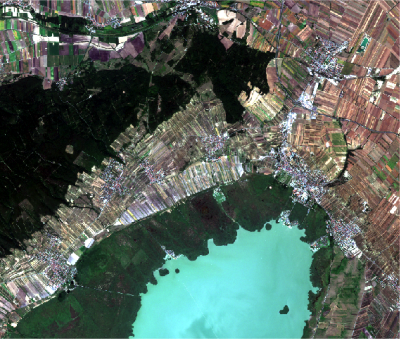

In [2]:
im = PIL.Image.open('lake.png')
im

In [3]:
data = np.asarray(im)

In [4]:
data.shape

(339, 400, 3)

In [5]:
data = data.reshape((-1,3))

In [6]:
data.shape

(135600, 3)

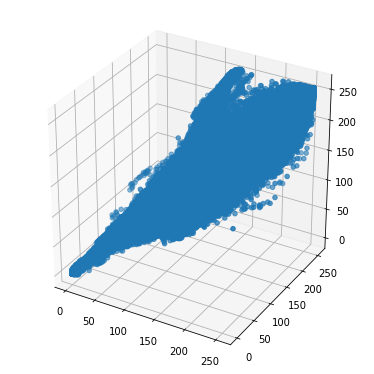

In [7]:
fig = plt.figure(figsize=(5, 5))
ax = Axes3D(fig)
ax.scatter3D(data[:,0],data[:,1],data[:,2])

In [8]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6)
kmeans.fit(data);

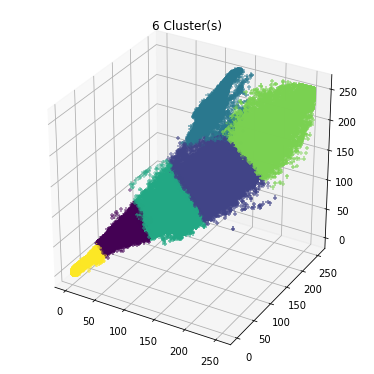

In [9]:
def plot_result_3d(kmeans):
    fig = plt.figure(figsize=(5, 5))
    ax = Axes3D(fig)
    ax.scatter3D(data[:,0],data[:,1],data[:,2],c=kmeans.labels_, marker='+')
    ax.set_title(str(kmeans.n_clusters) + ' Cluster(s)')
#     ax.view_init(0, 0)
plot_result_3d(kmeans)

In [10]:
colors=np.array([
    [255,0,0],
    [0,255,0],
    [0,0,255],
    [255,0,255],
    [255,255,0],
    [0,255,255],
    [0,0,0],    
])

In [11]:
newimg = kmeans.cluster_centers_[kmeans.labels_]
newimg2 = colors[kmeans.labels_]
newimg.shape

(135600, 3)

In [12]:
newimg = newimg.reshape(np.asarray(im).shape).astype('uint8')
newimg2 = newimg2.reshape(np.asarray(im).shape).astype('uint8')

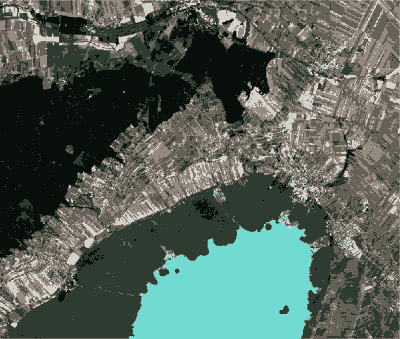

In [13]:
PIL.Image.fromarray(newimg)

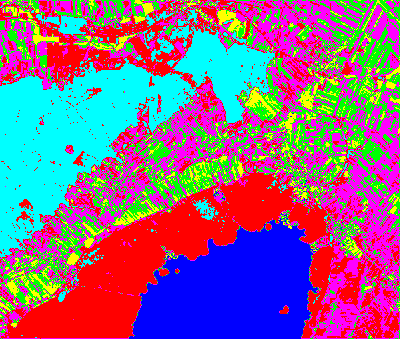

In [14]:
PIL.Image.fromarray(newimg2)